# Production-path WSI InstanSeg → watershed smoke test

This is an experimental end-to-end check of the proposed production path: it first creates a centered half-slide all-channel crop from the original 72-channel OME-TIFF, then the patched InstanSeg fork performs selected-channel global-normalized WSI inference with `resolve_cell_and_nucleus=False`, and the mIF-pipeline reconciles the two unresolved Zarr planes with the validated local watershed/proxy rules. It writes only a model-resolution reconciled Zarr after the crop.

This notebook is not yet production adoption. Run the cells in order; inference and reconciliation are explicitly gated.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import time
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.segmentation import watershed
import tifffile
import zarr

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
INSTANSEG_ROOT = (REPO_ROOT.parent / 'instanseg').resolve()
if not (INSTANSEG_ROOT / 'instanseg/inference_class.py').exists():
    raise FileNotFoundError(f'InstanSeg fork not found: {INSTANSEG_ROOT}')
loaded_instanseg = sys.modules.get('instanseg')
if loaded_instanseg is not None:
    loaded_path = Path(loaded_instanseg.__file__).resolve()
    if INSTANSEG_ROOT not in loaded_path.parents:
        raise RuntimeError(f'InstanSeg already loaded from {loaded_path}; restart the kernel.')
sys.path.insert(0, str(INSTANSEG_ROOT))
from tiffslide import TiffSlide
from instanseg import InstanSeg
import instanseg.inference_class as inference_class
inference_class.TiffSlide = TiffSlide

INSTANSEG_HEAD = subprocess.run(
    ['git', '-C', str(INSTANSEG_ROOT), 'rev-parse', 'HEAD'],
    check=True, text=True, capture_output=True,
).stdout.strip()
INSTANSEG_STATUS = subprocess.run(
    ['git', '-C', str(INSTANSEG_ROOT), 'status', '--short'],
    check=True, text=True, capture_output=True,
).stdout.strip()
PATCH_SENTINEL = 'nuclei_map_list = map_list if labels_are_matched else None'
if PATCH_SENTINEL not in (INSTANSEG_ROOT / 'instanseg/utils/tiling.py').read_text():
    raise RuntimeError('The selected InstanSeg checkout is missing the unresolved-nuclear stitching patch.')
if not hasattr(InstanSeg, 'eval_whole_slide_image_global_normalization'):
    raise AttributeError('The selected InstanSeg fork lacks the global-normalized WSI method.')
print({
    'python': sys.executable,
    'instanseg_root': str(INSTANSEG_ROOT),
    'instanseg_head': INSTANSEG_HEAD,
    'instanseg_worktree_dirty': bool(INSTANSEG_STATUS),
})

{'python': '/data1/lowes/ratnayn/conda_envs/instanseg_training/bin/python', 'instanseg_root': '/data1/lowes/ratnayn/Codex/projects/instanseg', 'instanseg_head': 'a705b26fadf045225d47ca006b9d2269339b4fc8', 'instanseg_worktree_dirty': True}


In [2]:
# Inputs and explicit gates. Keep all large artifacts in scratch.
SLIDE_ID = 'SLIDE-0330'
SOURCE_FULL_MERGE_OME = Path(
    '/data1/lowes/ratnayn/Data/CellDive_analysis_data/image_data/'
    'SLIDE-0330/outputs_v3/SLIDE-0330_full_merge.ome.tif'
)
SCRATCH_ROOT = Path('/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline')
OUTPUT_DIR = SCRATCH_ROOT / 'instanseg_watershed_production_smoke_all_channel_crop' / SLIDE_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_BUILD_CROP = True
OVERWRITE_CROP = True  # Required once to replace the known-corrupt buffered-tile crop.
RUN_WSI_INFERENCE = True
RUN_WATERSHED_RECONCILIATION = True
WRITE_RECONCILED_ZARR = True
OVERWRITE_WSI = True  # The previous WSI result used the corrupt crop.
OVERWRITE_RECONCILED = True
REBUILD_WORK_ARRAYS = True
ROW_CHUNK = 512
CROP_FRACTION = 0.5
CROP_IO_TILE = 512
CROP_WRITE_TILE = 512

CROP_OME = OUTPUT_DIR / f'{SLIDE_ID}_all_channels_half_crop.ome.tif'
CROP_TEMP_OME = Path(str(CROP_OME) + '.partial')
CROP_PROVENANCE_JSON = OUTPUT_DIR / f'{SLIDE_ID}_crop_provenance.json'
UNRESOLVED_ZARR = OUTPUT_DIR / f'{SLIDE_ID}_unresolved_global_wsi.zarr'
RECONCILED_ZARR = OUTPUT_DIR / f'{SLIDE_ID}_watershed_reconciled.zarr'
WORK_CELL_DAT = OUTPUT_DIR / f'{SLIDE_ID}_work_cells.uint32.dat'
WORK_NUCLEAR_DAT = OUTPUT_DIR / f'{SLIDE_ID}_work_nuclei.uint32.dat'
WORK_STATE_JSON = OUTPUT_DIR / f'{SLIDE_ID}_work_state.json'
PROVENANCE_JSON = OUTPUT_DIR / f'{SLIDE_ID}_experiment.json'
MAPPING_NPY = OUTPUT_DIR / f'{SLIDE_ID}_nucleus_to_final_cell.npy'

SEGMENTATION_CHANNELS = [
    'R1_DAPI', 'R4_P19_POLYRAT', 'R4_GFP_POLY_AF488',
    'R6_CD45_CST_AF647', 'R6_PANCK_AE1_AE3_750',
    'R12_CD31_D8V9E_AF750', 'R7_NAK_ATPASE_555',
    'R8_F480_D2S9R_555', 'R9_CD68_E3O7V_488',
    'R12_CD3E_E4T1B_AF555',
]
REFERENCE_CHANNEL = 'R1_DAPI'
MODEL_NAME = 'fluorescence_nuclei_and_cells'
PIXEL_SIZE_UM = 0.325
WSI_TILE_SIZE = 2048
WSI_OVERLAP = 80
WSI_DETECTION_SIZE = 20
WSI_BATCH_SIZE = 1
NORMALIZATION_PERCENTILES = (0.1, 99.9)
EVAL_KWARGS = {
    'min_size': 10, 'mask_threshold': 0.53, 'peak_distance': 5,
    'seed_threshold': 0.7, 'overlap_threshold': 0.3,
    'mean_threshold': 0.0, 'fg_threshold': 0.5, 'window_size': 32,
    'cleanup_fragments': True, 'resolve_cell_and_nucleus': False,
}
if WRITE_RECONCILED_ZARR and not RUN_WATERSHED_RECONCILIATION:
    raise ValueError('WRITE_RECONCILED_ZARR requires RUN_WATERSHED_RECONCILIATION=True.')
print({'output_dir': str(OUTPUT_DIR), 'run_wsi': RUN_WSI_INFERENCE, 'run_watershed': RUN_WATERSHED_RECONCILIATION})

{'output_dir': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_watershed_production_smoke_all_channel_crop/SLIDE-0330', 'run_wsi': True, 'run_watershed': True}


In [3]:
def parse_ome_xml(xml):
    root = ET.fromstring(xml or '')
    pixels = next(element for element in root.iter() if element.tag.endswith('Pixels'))
    channel_names = [
        element.attrib['Name'] for element in pixels
        if element.tag.endswith('Channel') and element.attrib.get('Name')
    ]
    return {
        'channel_names': channel_names,
        'physical_size_x': float(pixels.attrib['PhysicalSizeX']),
        'physical_size_y': float(pixels.attrib['PhysicalSizeY']),
    }

with tifffile.TiffFile(SOURCE_FULL_MERGE_OME) as handle:
    source_series = handle.series[0]
    source_shape = tuple(int(value) for value in source_series.shape)
    source_axes = source_series.axes
    source_dtype = str(source_series.dtype)
    source_ome = parse_ome_xml(handle.ome_metadata)
    source_names = source_ome['channel_names']
    source_page = source_series.levels[0].pages[0]
    source_layout = getattr(source_page, 'keyframe', source_page)
    source_tile_shape = (
        int(getattr(source_layout, 'tilelength', None) or CROP_IO_TILE),
        int(getattr(source_layout, 'tilewidth', None) or CROP_IO_TILE),
    )
if source_axes != 'CYX' or len(source_shape) != 3:
    raise ValueError(f'Expected a CYX source series, got {source_axes} {source_shape}.')
if source_dtype != 'uint16' or len(source_names) != source_shape[0]:
    raise ValueError(f'Expected uint16 data and one name per source channel, got {source_dtype} and {len(source_names)} names.')
if len(SEGMENTATION_CHANNELS) != len(set(SEGMENTATION_CHANNELS)):
    raise ValueError('SEGMENTATION_CHANNELS contains duplicates.')
missing = [name for name in SEGMENTATION_CHANNELS if name not in source_names]
if missing:
    raise ValueError(f'Missing segmentation channels: {missing}')
channel_to_index = {name: index for index, name in enumerate(source_names)}
CHANNEL_IDS = [channel_to_index[name] for name in SEGMENTATION_CHANNELS]
REFERENCE_CHANNEL_ID = channel_to_index[REFERENCE_CHANNEL]
if [source_names[index] for index in CHANNEL_IDS] != SEGMENTATION_CHANNELS:
    raise AssertionError('Channel alias-to-source-index order was not preserved.')
if REFERENCE_CHANNEL_ID not in CHANNEL_IDS:
    raise AssertionError('The acquisition reference channel must be selected.')
source_height, source_width = source_shape[-2:]
CROP_HEIGHT = max(16, int(source_height * CROP_FRACTION) // 16 * 16)
CROP_WIDTH = max(16, int(source_width * CROP_FRACTION) // 16 * 16)
CROP_Y = ((source_height - CROP_HEIGHT) // 2) // 16 * 16
CROP_X = ((source_width - CROP_WIDTH) // 2) // 16 * 16
if CROP_HEIGHT > source_height or CROP_WIDTH > source_width:
    raise ValueError('Centered crop is larger than its source dimension.')

CROP_CONFIG = {
    'source_image': str(SOURCE_FULL_MERGE_OME),
    'source_file_size_bytes': SOURCE_FULL_MERGE_OME.stat().st_size,
    'source_file_mtime_ns': SOURCE_FULL_MERGE_OME.stat().st_mtime_ns,
    'source_shape': list(source_shape), 'source_axes': source_axes,
    'source_dtype': source_dtype, 'source_channel_names': source_names,
    'source_tile_shape': list(source_tile_shape),
    'source_physical_size_x_um': source_ome['physical_size_x'],
    'source_physical_size_y_um': source_ome['physical_size_y'],
    'crop_box_xywh': [CROP_X, CROP_Y, CROP_WIDTH, CROP_HEIGHT],
    'crop_shape': [len(source_names), CROP_HEIGHT, CROP_WIDTH],
    'crop_fraction_each_axis': CROP_FRACTION,
    'crop_io_tile': CROP_IO_TILE, 'crop_write_tile': CROP_WRITE_TILE,
    'crop_image': str(CROP_OME),
}

def validate_crop(path, *, require_provenance=True):
    if not path.exists():
        raise FileNotFoundError(path)
    if require_provenance:
        if not CROP_PROVENANCE_JSON.exists():
            raise FileNotFoundError(CROP_PROVENANCE_JSON)
        prior = json.loads(CROP_PROVENANCE_JSON.read_text())
        if prior.get('config') != CROP_CONFIG or prior.get('status') != 'complete':
            raise RuntimeError('Existing crop provenance does not match this source/crop.')
    with tifffile.TiffFile(path) as handle:
        series = handle.series[0]
        if series.axes != 'CYX' or tuple(series.shape) != tuple(CROP_CONFIG['crop_shape']):
            raise RuntimeError(f'Crop axes/shape mismatch: {series.axes} {series.shape}')
        if str(series.dtype) != 'uint16':
            raise RuntimeError(f'Crop dtype mismatch: {series.dtype}')
        info = parse_ome_xml(handle.ome_metadata)
        if info['channel_names'] != source_names:
            raise RuntimeError('Crop channel names/order do not match the full source.')
        if not np.isclose(info['physical_size_x'], source_ome['physical_size_x']) or not np.isclose(info['physical_size_y'], source_ome['physical_size_y']):
            raise RuntimeError('Crop physical pixel metadata does not match the source.')
        page = series.levels[0].pages[0]
        layout = getattr(page, 'keyframe', page)
        actual_tile = (int(getattr(layout, 'tilelength', 0) or 0), int(getattr(layout, 'tilewidth', 0) or 0))
        if actual_tile != (CROP_WRITE_TILE, CROP_WRITE_TILE):
            raise RuntimeError(f'Crop is not written with the expected tiled layout: {actual_tile}')
    with TiffSlide(str(path)) as slide:
        if slide.dimensions != (CROP_WIDTH, CROP_HEIGHT):
            raise RuntimeError(f'TiffSlide crop dimensions mismatch: {slide.dimensions}')
    # Content validation is essential: metadata alone cannot detect a TIFF
    # whose mutable tile buffer was overwritten during asynchronous compression.
    sample_channels = sorted(set([0, REFERENCE_CHANNEL_ID, len(source_names) - 1]))
    sample_origins = [
        (0, 0),
        (0, max(0, CROP_WIDTH - CROP_WRITE_TILE)),
        (max(0, CROP_HEIGHT - CROP_WRITE_TILE), 0),
        (max(0, CROP_HEIGHT - CROP_WRITE_TILE), max(0, CROP_WIDTH - CROP_WRITE_TILE)),
        (max(0, CROP_HEIGHT // 2 - CROP_WRITE_TILE // 2), max(0, CROP_WIDTH // 2 - CROP_WRITE_TILE // 2)),
    ]
    with tifffile.TiffFile(SOURCE_FULL_MERGE_OME) as source_handle, tifffile.TiffFile(path) as crop_handle:
        source_store = source_handle.series[0].aszarr(level=0)
        crop_store = crop_handle.series[0].aszarr(level=0)
        source_array = zarr.open(source_store, mode='r')
        crop_array = zarr.open(crop_store, mode='r')
        try:
            for channel_id in sample_channels:
                for y0, x0 in sample_origins:
                    y1 = min(CROP_HEIGHT, y0 + CROP_WRITE_TILE)
                    x1 = min(CROP_WIDTH, x0 + CROP_WRITE_TILE)
                    expected = np.asarray(source_array.oindex[channel_id, slice(CROP_Y + y0, CROP_Y + y1), slice(CROP_X + x0, CROP_X + x1)])
                    observed = np.asarray(crop_array.oindex[channel_id, slice(y0, y1), slice(x0, x1)])
                    if not np.array_equal(observed, expected):
                        raise RuntimeError(f'Crop pixels differ from source for channel {channel_id} at {(y0, x0)}.')
        finally:
            source_store.close()
            crop_store.close()
    return path

def read_full_crop():
    total_gib = np.prod(CROP_CONFIG['crop_shape']) * np.dtype(np.uint16).itemsize / 2**30
    print(f'[crop] allocating {total_gib:.1f} GiB uint16 crop array', flush=True)
    crop = np.empty(tuple(CROP_CONFIG['crop_shape']), dtype=np.uint16)
    read_started = time.perf_counter()
    with tifffile.TiffFile(str(SOURCE_FULL_MERGE_OME)) as handle:
        source_store = handle.series[0].aszarr(level=0)
        source = zarr.open(source_store, mode='r')
        try:
            for channel_id, channel_name in enumerate(source_names):
                channel_started = time.perf_counter()
                print(f'[crop] reading channel {channel_id + 1}/{len(source_names)} {channel_name} ...', flush=True)
                crop[channel_id] = np.asarray(source.oindex[channel_id, slice(CROP_Y, CROP_Y + CROP_HEIGHT), slice(CROP_X, CROP_X + CROP_WIDTH)])
                print(
                    f'[crop] read channel {channel_id + 1}/{len(source_names)} in '
                    f'{time.perf_counter() - channel_started:.1f} s '
                    f'(total {(time.perf_counter() - read_started) / 60:.1f} min)',
                    flush=True,
                )
        finally:
            source_store.close()
    if crop.shape != tuple(CROP_CONFIG['crop_shape']) or crop.dtype != np.uint16:
        raise RuntimeError(f'Unexpected in-memory crop: {crop.shape} {crop.dtype}')
    return crop

def write_crop():
    overall_started = time.perf_counter()
    print('[crop] stage 1/4: reading the full all-channel crop into memory', flush=True)
    crop = read_full_crop()
    print(f'[crop] stage 1/4 complete in {(time.perf_counter() - overall_started) / 60:.1f} min', flush=True)
    ome = tifffile.OmeXml()
    ome.addimage(
        dtype=crop.dtype, shape=crop.shape,
        storedshape=(crop.shape[0], 1, 1, crop.shape[1], crop.shape[2], 1),
        axes='CYX', Channel={'Name': source_names},
        PhysicalSizeX=source_ome['physical_size_x'],
        PhysicalSizeY=source_ome['physical_size_y'],
    )
    CROP_TEMP_OME.unlink(missing_ok=True)
    try:
        print(f'[crop] stage 2/4: writing compressed temporary OME-TIFF {CROP_TEMP_OME}', flush=True)
        write_started = time.perf_counter()
        # Match the proven mIF-pipeline merge writer: one complete 2D
        # channel array per TIFF page, explicit OME description on page 0.
        with tifffile.TiffWriter(CROP_TEMP_OME, bigtiff=True, ome=False) as writer:
            for channel_id, channel_name in enumerate(source_names):
                channel_started = time.perf_counter()
                print(f'[crop] writing channel {channel_id + 1}/{len(source_names)} {channel_name} ...', flush=True)
                kwargs = {
                    'tile': (CROP_WRITE_TILE, CROP_WRITE_TILE),
                    'compression': 'zlib', 'photometric': 'minisblack',
                    'metadata': None,
                }
                if channel_id == 0:
                    kwargs['description'] = ome.tostring()
                writer.write(crop[channel_id], **kwargs)
                print(
                    f'[crop] wrote channel {channel_id + 1}/{len(source_names)} in '
                    f'{time.perf_counter() - channel_started:.1f} s '
                    f'(write total {(time.perf_counter() - write_started) / 60:.1f} min)',
                    flush=True,
                )
        print(f'[crop] stage 2/4 complete in {(time.perf_counter() - write_started) / 60:.1f} min', flush=True)
        print('[crop] stage 3/4: validating TIFF metadata and sampled pixels against the source', flush=True)
        validation_started = time.perf_counter()
        validate_crop(CROP_TEMP_OME, require_provenance=False)
        print(f'[crop] stage 3/4 complete in {time.perf_counter() - validation_started:.1f} s', flush=True)
        print('[crop] stage 4/4: replacing the previous crop with the validated TIFF', flush=True)
        CROP_TEMP_OME.replace(CROP_OME)
        print(f'[crop] complete in {(time.perf_counter() - overall_started) / 60:.1f} min: {CROP_OME}', flush=True)
    except Exception:
        CROP_TEMP_OME.unlink(missing_ok=True)
        raise
    finally:
        del crop
    CROP_PROVENANCE_JSON.write_text(json.dumps({'status': 'complete', 'config': CROP_CONFIG}, indent=2) + '\n')

CROP_RAN_THIS_INVOCATION = False
if RUN_BUILD_CROP and (OVERWRITE_CROP or not CROP_OME.exists()):
    write_crop()
    CROP_RAN_THIS_INVOCATION = True
elif RUN_BUILD_CROP and CROP_OME.exists():
    validate_crop(CROP_OME)
elif not CROP_OME.exists():
    raise FileNotFoundError('Set RUN_BUILD_CROP=True or provide the all-channel crop.')
if not CROP_PROVENANCE_JSON.exists():
    raise FileNotFoundError(CROP_PROVENANCE_JSON)
validate_crop(CROP_OME)

if CROP_RAN_THIS_INVOCATION:
    stale = []
    if UNRESOLVED_ZARR.exists() and not (RUN_WSI_INFERENCE and OVERWRITE_WSI):
        stale.append('RUN_WSI_INFERENCE=True and OVERWRITE_WSI=True')
    if WORK_STATE_JSON.exists() and not (RUN_WATERSHED_RECONCILIATION and REBUILD_WORK_ARRAYS):
        stale.append('RUN_WATERSHED_RECONCILIATION=True and REBUILD_WORK_ARRAYS=True')
    if RECONCILED_ZARR.exists() and not (WRITE_RECONCILED_ZARR and OVERWRITE_RECONCILED):
        stale.append('WRITE_RECONCILED_ZARR=True and OVERWRITE_RECONCILED=True')
    if stale:
        raise RuntimeError('Fresh crop requires downstream regeneration; set ' + ', '.join(stale) + '.')

INFERENCE_IMAGE = CROP_OME
CONFIG = {
    'slide_id': SLIDE_ID, 'source_image': str(INFERENCE_IMAGE),
    'original_source_image': str(SOURCE_FULL_MERGE_OME),
    'crop_provenance': str(CROP_PROVENANCE_JSON),
    'crop_box_xywh': [CROP_X, CROP_Y, CROP_WIDTH, CROP_HEIGHT],
    'crop_shape': list(CROP_CONFIG['crop_shape']),
    'source_channel_names': source_names,
    'source_shape': list(source_shape), 'source_dtype': source_dtype,
    'channels': SEGMENTATION_CHANNELS, 'channel_ids': CHANNEL_IDS,
    'reference_channel': REFERENCE_CHANNEL, 'reference_channel_id': REFERENCE_CHANNEL_ID,
    'model': MODEL_NAME, 'pixel_size_um': PIXEL_SIZE_UM,
    'normalization_percentiles': list(NORMALIZATION_PERCENTILES),
    'tile_size': WSI_TILE_SIZE, 'overlap': WSI_OVERLAP,
    'detection_size': WSI_DETECTION_SIZE, 'batch_size': WSI_BATCH_SIZE,
    'eval_kwargs': EVAL_KWARGS, 'resolve_cell_and_nucleus': False,
    'instanseg_root': str(INSTANSEG_ROOT), 'instanseg_head': INSTANSEG_HEAD,
    'instanseg_worktree_status': INSTANSEG_STATUS,
}
if PROVENANCE_JSON.exists():
    previous = json.loads(PROVENANCE_JSON.read_text())
    if previous.get('config') != CONFIG:
        raise RuntimeError('Existing experiment provenance does not match this configuration.')
elif UNRESOLVED_ZARR.exists():
    raise RuntimeError('An unresolved Zarr exists without experiment provenance; refusing unsafe reuse.')
else:
    PROVENANCE_JSON.write_text(json.dumps({'status': 'configured', 'config': CONFIG}, indent=2) + '\n')
print({
    'original_source_shape': source_shape, 'crop_box_xywh': [CROP_X, CROP_Y, CROP_WIDTH, CROP_HEIGHT],
    'crop_shape': tuple(CROP_CONFIG['crop_shape']),
    'selected_source_channels': list(zip(SEGMENTATION_CHANNELS, CHANNEL_IDS)),
    'estimated_uncompressed_crop_gib': source_shape[0] * CROP_HEIGHT * CROP_WIDTH * 2 / 2**30,
    'crop_path': str(CROP_OME), 'crop_ran_this_invocation': CROP_RAN_THIS_INVOCATION,
})

[crop] stage 1/4: reading the full all-channel crop into memory
[crop] allocating 116.4 GiB uint16 crop array
[crop] reading channel 1/72 R1_DAPI_AF ...
[crop] read channel 1/72 in 6.0 s (total 0.1 min)
[crop] reading channel 2/72 R1_BIT2_RS0584_CY3B ...
[crop] read channel 2/72 in 5.3 s (total 0.2 min)
[crop] reading channel 3/72 R1_BIT3_RS0015_CY5 ...
[crop] read channel 3/72 in 5.2 s (total 0.3 min)
[crop] reading channel 4/72 R1_BIT4_RS0083_750 ...
[crop] read channel 4/72 in 5.4 s (total 0.4 min)
[crop] reading channel 5/72 R1_DAPI ...
[crop] read channel 5/72 in 6.0 s (total 0.5 min)
[crop] reading channel 6/72 R1_BIT1_RS0996_488 ...
[crop] read channel 6/72 in 5.4 s (total 0.6 min)
[crop] reading channel 7/72 R10_DAPI_AF ...
[crop] read channel 7/72 in 5.7 s (total 0.6 min)
[crop] reading channel 8/72 R10_CD206_E6T5J_AF555 ...
[crop] read channel 8/72 in 5.0 s (total 0.7 min)
[crop] reading channel 9/72 R10_N_ELASTASE_E8U3X_647 ...
[crop] read channel 9/72 in 3.3 s (total 0.8 mi

## WSI inference and safe reuse

The unresolved Zarr is accepted only when it is complete and its source, ordered channels, WSI settings, normalization settings, and unresolved mode match this notebook.

In [4]:
def validate_unresolved_zarr(path):
    if not path.exists():
        raise FileNotFoundError(path)
    array = zarr.open(str(path), mode='r')
    attrs = dict(array.attrs)
    if attrs.get('status') != 'complete':
        raise RuntimeError(f'Unresolved Zarr is not complete: {path}')
    if array.ndim != 3 or tuple(array.shape[:1]) != (2,) or np.dtype(array.dtype) != np.dtype(np.int32):
        raise RuntimeError(f'Unexpected unresolved Zarr shape/dtype: {array.shape}, {array.dtype}')
    if attrs.get('source_image') != str(INFERENCE_IMAGE):
        raise RuntimeError('Unresolved Zarr source image does not match.')
    if not np.isclose(float(attrs.get('source_pixel_size_um', np.nan)), PIXEL_SIZE_UM):
        raise RuntimeError('Unresolved Zarr source pixel size does not match.')
    if list(attrs.get('channel_ids', [])) != CHANNEL_IDS:
        raise RuntimeError('Unresolved Zarr channel order does not match.')
    if attrs.get('planes') != ['nuclei', 'cells']:
        raise RuntimeError('Unresolved Zarr plane order does not match.')
    settings = attrs.get('wsi_settings', {})
    for key, expected in {'tile_size': WSI_TILE_SIZE, 'overlap': WSI_OVERLAP, 'detection_size': WSI_DETECTION_SIZE}.items():
        if int(settings.get(key, -1)) != expected:
            raise RuntimeError(f'Unresolved Zarr WSI setting {key} does not match.')
    if settings.get('resolve_cell_and_nucleus') is not False:
        raise RuntimeError('Unresolved Zarr was not generated with resolve_cell_and_nucleus=False.')
    normalization = attrs.get('normalization', {})
    if list(normalization.get('channel_ids', [])) != CHANNEL_IDS:
        raise RuntimeError('Unresolved Zarr normalization channels do not match.')
    if int(normalization.get('reference_channel_id', -1)) != REFERENCE_CHANNEL_ID:
        raise RuntimeError('Unresolved Zarr normalization reference channel does not match.')
    percentiles = normalization.get('percentiles')
    if percentiles is None or not np.allclose(percentiles, NORMALIZATION_PERCENTILES):
        raise RuntimeError('Unresolved Zarr normalization percentiles do not match.')
    return array

WSI_RAN_THIS_INVOCATION = False
if RUN_WSI_INFERENCE and (not UNRESOLVED_ZARR.exists() or OVERWRITE_WSI):
    WSI_RAN_THIS_INVOCATION = True
    started = time.perf_counter()
    inst = InstanSeg(MODEL_NAME, verbosity=1)
    observed_path = inst.eval_whole_slide_image_global_normalization(
        str(INFERENCE_IMAGE), channel_ids=CHANNEL_IDS, pixel_size=PIXEL_SIZE_UM,
        normalization_percentiles=NORMALIZATION_PERCENTILES,
        reference_channel_id=REFERENCE_CHANNEL_ID, tile_size=WSI_TILE_SIZE,
        overlap=WSI_OVERLAP, detection_size=WSI_DETECTION_SIZE,
        batch_size=WSI_BATCH_SIZE, output_path=UNRESOLVED_ZARR,
        overwrite=OVERWRITE_WSI, **EVAL_KWARGS,
    )
    raw = validate_unresolved_zarr(Path(observed_path))
    print({'wsi_minutes': (time.perf_counter() - started) / 60, 'path': str(observed_path)})
elif UNRESOLVED_ZARR.exists():
    raw = validate_unresolved_zarr(UNRESOLVED_ZARR)
    print({'reused_unresolved_zarr': str(UNRESOLVED_ZARR)})
else:
    raise FileNotFoundError('Set RUN_WSI_INFERENCE=True or provide the completed unresolved Zarr.')

model_shape = tuple(int(value) for value in raw.shape[-2:])
PROVENANCE_JSON.write_text(json.dumps({'status': 'wsi_complete', 'config': CONFIG, 'unresolved_zarr': str(UNRESOLVED_ZARR)}, indent=2) + '\n')
print({'shape': tuple(raw.shape), 'chunks': raw.chunks, 'dtype': str(raw.dtype), 'model_shape': model_shape})

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/../bioimageio_models/, loading
Requesting default device: cuda


Slide progress:   1%|          | 1/110 [00:03<06:45,  3.72s/it]/data1/lowes/ratnayn/Codex/projects/instanseg/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  intersection = torch.sparse.mm(onehot1, onehot2.T).to_dense()
Slide progress: 100%|██████████| 110/110 [06:46<00:00,  3.69s/it]

{'wsi_minutes': 7.3020953308170045, 'path': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_watershed_production_smoke_all_channel_crop/SLIDE-0330/SLIDE-0330_unresolved_global_wsi.zarr'}
{'shape': (2, 17992, 20374), 'chunks': (1, 2048, 2048), 'dtype': 'int32', 'model_shape': (17992, 20374)}


## Chunked watershed reconciliation

The unresolved Zarr remains immutable. The two planes are copied row-chunkwise into disk-backed `uint32` arrays. Association uses strict greater-than-50% nucleus overlap; only ambiguous parents are split locally; unseeded parent territory is retained; nuclei take priority; unmatched nuclei become exact proxy cells.

In [5]:
def copy_plane(source, plane, destination, shape):
    target = np.memmap(destination, mode='w+', dtype=np.uint32, shape=shape)
    maximum = 0
    for y0 in range(0, shape[0], ROW_CHUNK):
        y1 = min(shape[0], y0 + ROW_CHUNK)
        block = np.asarray(source[plane, y0:y1], dtype=np.uint32)
        target[y0:y1] = block
        if block.size:
            maximum = max(maximum, int(block.max()))
    target.flush()
    return target, maximum

def reduce_code_counts(code_parts, count_parts):
    if not code_parts:
        return np.array([], dtype=np.uint64), np.array([], dtype=np.int64)
    codes = np.concatenate(code_parts)
    counts = np.concatenate(count_parts)
    order = np.argsort(codes)
    codes, counts = codes[order], counts[order]
    starts = np.r_[0, np.flatnonzero(codes[1:] != codes[:-1]) + 1]
    return codes[starts], np.add.reduceat(counts, starts)

def overlap_counts(cells, nuclei, max_cell_id, max_nucleus_id):
    cell_areas = np.zeros(max_cell_id + 1, dtype=np.int64)
    nucleus_areas = np.zeros(max_nucleus_id + 1, dtype=np.int64)
    base = np.uint64(max_nucleus_id + 1)
    code_parts, count_parts = [], []
    for y0 in range(0, cells.shape[0], ROW_CHUNK):
        y1 = min(cells.shape[0], y0 + ROW_CHUNK)
        cell_block = np.asarray(cells[y0:y1])
        nucleus_block = np.asarray(nuclei[y0:y1])
        cell_areas += np.bincount(cell_block.ravel(), minlength=max_cell_id + 1)
        nucleus_areas += np.bincount(nucleus_block.ravel(), minlength=max_nucleus_id + 1)
        both = (cell_block > 0) & (nucleus_block > 0)
        if np.any(both):
            codes, counts = np.unique(
                cell_block[both].astype(np.uint64) * base + nucleus_block[both].astype(np.uint64),
                return_counts=True,
            )
            code_parts.append(codes)
            count_parts.append(counts.astype(np.int64, copy=False))
    codes, counts = reduce_code_counts(code_parts, count_parts)
    return (
        cell_areas, nucleus_areas, (codes // base).astype(np.uint32),
        (codes % base).astype(np.uint32), counts,
    )

def combine_slices(slices, margin, shape):
    return (
        slice(max(0, min(item[0].start for item in slices) - margin), min(shape[0], max(item[0].stop for item in slices) + margin)),
        slice(max(0, min(item[1].start for item in slices) - margin), min(shape[1], max(item[1].stop for item in slices) + margin)),
    )

def split_parent_local(cells, nuclei, cell_id, nucleus_ids, bbox):
    cell_crop = cells[bbox]
    nucleus_crop = nuclei[bbox]
    parent = cell_crop == cell_id
    territory = parent.copy()
    markers = np.zeros(parent.shape, dtype=np.int32)
    for marker_id, nucleus_id in enumerate(nucleus_ids, start=1):
        nucleus = nucleus_crop == nucleus_id
        territory |= nucleus
        markers[nucleus] = marker_id
    components, _ = ndi.label(territory)
    seeded_ids = np.unique(components[markers > 0])
    seeded_ids = seeded_ids[seeded_ids > 0]
    seeded_territory = np.isin(components, seeded_ids)
    split = watershed(-ndi.distance_transform_edt(seeded_territory), markers=markers, mask=seeded_territory)
    return parent, seeded_territory, markers, split

if RUN_WATERSHED_RECONCILIATION:
    state = json.loads(WORK_STATE_JSON.read_text()) if WORK_STATE_JSON.exists() else None
    if REBUILD_WORK_ARRAYS or WSI_RAN_THIS_INVOCATION or state is None:
        final_nuclei, max_raw_nucleus_id = copy_plane(raw, 0, WORK_NUCLEAR_DAT, model_shape)
        final_cells, max_raw_cell_id = copy_plane(raw, 1, WORK_CELL_DAT, model_shape)
        state = {'state': 'raw_unresolved', 'shape': list(model_shape), 'max_raw_cell_id': max_raw_cell_id, 'max_raw_nucleus_id': max_raw_nucleus_id, 'config': CONFIG}
        WORK_STATE_JSON.write_text(json.dumps(state, indent=2) + '\n')
    elif state.get('state') == 'raw_unresolved':
        if state.get('config') != CONFIG or tuple(state.get('shape', ())) != model_shape:
            raise RuntimeError('Existing working arrays do not match this experiment; set REBUILD_WORK_ARRAYS=True.')
        final_nuclei = np.memmap(WORK_NUCLEAR_DAT, mode='r+', dtype=np.uint32, shape=model_shape)
        final_cells = np.memmap(WORK_CELL_DAT, mode='r+', dtype=np.uint32, shape=model_shape)
        max_raw_nucleus_id = int(state['max_raw_nucleus_id'])
        max_raw_cell_id = int(state['max_raw_cell_id'])
    elif state.get('state') == 'final_reconciled':
        if state.get('config') != CONFIG or tuple(state.get('shape', ())) != model_shape:
            raise RuntimeError('Existing final working arrays do not match this experiment; set REBUILD_WORK_ARRAYS=True.')
        if not MAPPING_NPY.exists():
            raise FileNotFoundError(MAPPING_NPY)
        final_nuclei = np.memmap(WORK_NUCLEAR_DAT, mode='r', dtype=np.uint32, shape=model_shape)
        final_cells = np.memmap(WORK_CELL_DAT, mode='r', dtype=np.uint32, shape=model_shape)
        max_raw_nucleus_id = int(state['max_raw_nucleus_id'])
        max_raw_cell_id = int(state['max_raw_cell_id'])
    else:
        raise RuntimeError(f'Unknown work-array state: {state.get("state")!r}')
    print({'work_state': state.get('state'), 'model_shape': model_shape})
else:
    print('Set RUN_WATERSHED_RECONCILIATION=True to build or reopen working arrays.')

{'work_state': 'raw_unresolved', 'model_shape': (17992, 20374)}


In [6]:
RECONCILIATION_RAN_THIS_INVOCATION = False
if (RUN_WATERSHED_RECONCILIATION and state.get('state') == 'raw_unresolved'
        and RECONCILED_ZARR.exists() and not OVERWRITE_RECONCILED):
    raise RuntimeError('Fresh reconciliation requires OVERWRITE_RECONCILED=True when the output Zarr already exists.')
if RUN_WATERSHED_RECONCILIATION and state.get('state') == 'raw_unresolved':
    started = time.perf_counter()
    raw_cell_areas, raw_nucleus_areas, pair_cells, pair_nuclei, pair_pixels = overlap_counts(
        final_cells, final_nuclei, max_raw_cell_id, max_raw_nucleus_id
    )
    qualifies = pair_pixels / raw_nucleus_areas[pair_nuclei] > 0.5
    qualifying_by_cell = {}
    for cell_id, nucleus_id in zip(pair_cells[qualifies].astype(int), pair_nuclei[qualifies].astype(int)):
        qualifying_by_cell.setdefault(cell_id, []).append(nucleus_id)
    raw_cell_ids = np.flatnonzero(raw_cell_areas[1:]) + 1
    raw_nucleus_ids = np.flatnonzero(raw_nucleus_areas[1:]) + 1
    matched = np.zeros(max_raw_nucleus_id + 1, dtype=bool)
    matched[pair_nuclei[qualifies]] = True
    unmatched_nucleus_ids = raw_nucleus_ids[~matched[raw_nucleus_ids]]
    ambiguous_cell_ids = np.array([cell_id for cell_id, ids in qualifying_by_cell.items() if len(ids) > 1], dtype=np.int64)
    association_summary = {
        'raw_cells': int(len(raw_cell_ids)), 'raw_nuclei': int(len(raw_nucleus_ids)),
        'single_nucleus_cells': int(sum(len(ids) == 1 for ids in qualifying_by_cell.values())),
        'ambiguous_cells': int(len(ambiguous_cell_ids)),
        'unmatched_nuclei': int(len(unmatched_nucleus_ids)),
        'seconds': time.perf_counter() - started,
    }
    cell_slices = ndi.find_objects(final_cells, max_label=max_raw_cell_id)
    nucleus_slices = ndi.find_objects(final_nuclei, max_label=max_raw_nucleus_id)
    nucleus_to_final_cell = np.zeros(max_raw_nucleus_id + 1, dtype=np.uint32)
    next_cell_id = max_raw_cell_id + 1
    split_count = 0
    unseeded_parent_pixels = 0
    all_seeded_unions_complete = True
    all_seed_checks_pass = True
    all_unseeded_parent_territory_preserved = True
    for cell_id, associated in qualifying_by_cell.items():
        if len(associated) == 1:
            nucleus_to_final_cell[associated[0]] = cell_id
            continue
        objects = [cell_slices[cell_id - 1]] + [nucleus_slices[nucleus_id - 1] for nucleus_id in associated]
        if not all(item is not None for item in objects):
            raise RuntimeError(f'Missing bounding box for ambiguous cell {cell_id}.')
        bbox = combine_slices(objects, margin=8, shape=model_shape)
        parent, seeded_territory, markers, split = split_parent_local(final_cells, final_nuclei, cell_id, associated, bbox)
        seeded_complete = bool(np.array_equal(split > 0, seeded_territory))
        seed_checks = all(
            np.any(markers == marker_id) and np.all(split[markers == marker_id] == marker_id)
            for marker_id in range(1, len(associated) + 1)
        )
        local_output = final_cells[bbox]
        seeded_parent = parent & seeded_territory
        unseeded_parent = parent & ~seeded_territory
        unseeded_count = int(unseeded_parent.sum())
        local_output[seeded_parent] = 0
        daughter_ids = [cell_id] + list(range(next_cell_id, next_cell_id + len(associated) - 1))
        next_cell_id += len(associated) - 1
        for marker_id, (nucleus_id, daughter_id) in enumerate(zip(associated, daughter_ids), start=1):
            local_output[(split == marker_id) & parent] = daughter_id
            nucleus_to_final_cell[nucleus_id] = daughter_id
        territory_preserved = bool(np.all(local_output[unseeded_parent] == cell_id))
        if not (seeded_complete and seed_checks and territory_preserved):
            raise AssertionError(f'Watershed validation failed for parent cell {cell_id}.')
        split_count += 1
        unseeded_parent_pixels += unseeded_count
        all_seeded_unions_complete &= seeded_complete
        all_seed_checks_pass &= seed_checks
        all_unseeded_parent_territory_preserved &= territory_preserved
    proxy_start_id = next_cell_id
    for nucleus_id in unmatched_nucleus_ids.astype(int):
        nucleus_to_final_cell[nucleus_id] = next_cell_id
        next_cell_id += 1
    proxy_stop_id = next_cell_id
    if not np.all(nucleus_to_final_cell[raw_nucleus_ids] > 0):
        raise AssertionError('At least one raw nucleus was not assigned a final cell ID.')
    if len(np.unique(nucleus_to_final_cell[raw_nucleus_ids])) != len(raw_nucleus_ids):
        raise AssertionError('Two raw nuclei were assigned the same final cell ID.')

    for y0 in range(0, model_shape[0], ROW_CHUNK):
        y1 = min(model_shape[0], y0 + ROW_CHUNK)
        nucleus_block = final_nuclei[y0:y1]
        mapped = nucleus_to_final_cell[nucleus_block]
        final_cells[y0:y1][mapped > 0] = mapped[mapped > 0]
        nucleus_block[:] = mapped
    final_cells.flush()
    final_nuclei.flush()
    np.save(MAPPING_NPY, nucleus_to_final_cell)
    territory_validation = {
        'ambiguous_cells': split_count,
        'all_seeded_unions_complete': bool(all_seeded_unions_complete),
        'all_seed_checks_pass': bool(all_seed_checks_pass),
        'all_unseeded_parent_territory_preserved': bool(all_unseeded_parent_territory_preserved),
        'unseeded_parent_pixels_preserved': unseeded_parent_pixels,
    }
    RECONCILIATION_RAN_THIS_INVOCATION = True
    state = {
        'state': 'final_reconciled', 'shape': list(model_shape),
        'max_raw_cell_id': max_raw_cell_id, 'max_raw_nucleus_id': max_raw_nucleus_id,
        'max_final_cell_id': next_cell_id - 1,
        'proxy_start_id': proxy_start_id, 'proxy_stop_id': proxy_stop_id,
        'mapping': str(MAPPING_NPY), 'config': CONFIG,
        'association_summary': association_summary,
        'territory_validation': territory_validation,
    }
    WORK_STATE_JSON.write_text(json.dumps(state, indent=2) + '\n')
    print({'association': association_summary, 'territory': territory_validation, 'minutes': (time.perf_counter() - started) / 60})
elif RUN_WATERSHED_RECONCILIATION and state.get('state') == 'final_reconciled':
    nucleus_to_final_cell = np.load(MAPPING_NPY, mmap_mode='r')
    max_raw_nucleus_id = int(state['max_raw_nucleus_id'])
    next_cell_id = int(state['max_final_cell_id']) + 1
    proxy_start_id = int(state['proxy_start_id'])
    proxy_stop_id = int(state['proxy_stop_id'])
    association_summary = state['association_summary']
    territory_validation = state['territory_validation']
    print({'reused_final_work_arrays': True, 'association': association_summary, 'territory': territory_validation})

{'association': {'raw_cells': 559013, 'raw_nuclei': 554137, 'single_nucleus_cells': 484595, 'ambiguous_cells': 18548, 'unmatched_nuclei': 32057, 'seconds': 5.326426425948739}, 'territory': {'ambiguous_cells': 18548, 'all_seeded_unions_complete': True, 'all_seed_checks_pass': True, 'all_unseeded_parent_territory_preserved': True, 'unseeded_parent_pixels_preserved': 107}, 'minutes': 0.41749298792953293}


## Strict validation and reconciled Zarr

Validation runs before the output Zarr can be marked complete. It checks exact raw-nucleus preservation and one-to-one final coordination, not just foreground counts.

In [7]:
def raw_nucleus_areas_from_zarr(source, max_label):
    areas = np.zeros(max_label + 1, dtype=np.int64)
    for y0 in range(0, model_shape[0], ROW_CHUNK):
        y1 = min(model_shape[0], y0 + ROW_CHUNK)
        areas += np.bincount(np.asarray(source[0, y0:y1]).ravel(), minlength=max_label + 1)
    return areas

if RUN_WATERSHED_RECONCILIATION:
    raw_nucleus_areas = raw_nucleus_areas_from_zarr(raw, max_raw_nucleus_id)
    raw_nucleus_ids = np.flatnonzero(raw_nucleus_areas[1:]) + 1
    mapped_ids = np.asarray(nucleus_to_final_cell[raw_nucleus_ids], dtype=np.uint32)
    if np.any(mapped_ids == 0) or len(np.unique(mapped_ids)) != len(raw_nucleus_ids):
        raise AssertionError('Every raw nucleus must map to one unique positive final cell ID.')
    max_final_id = int(next_cell_id - 1)
    final_cell_areas = np.zeros(max_final_id + 1, dtype=np.int64)
    final_nucleus_areas = np.zeros(max_final_id + 1, dtype=np.int64)
    nuclear_map_mismatches = 0
    nuclear_cell_mismatches = 0
    proxy_mismatches = 0
    raw_nuclear_pixels = 0
    final_nuclear_pixels = 0
    for y0 in range(0, model_shape[0], ROW_CHUNK):
        y1 = min(model_shape[0], y0 + ROW_CHUNK)
        raw_nuclei = np.asarray(raw[0, y0:y1])
        final_nuclei_block = np.asarray(final_nuclei[y0:y1])
        final_cells_block = np.asarray(final_cells[y0:y1])
        mapped_raw = nucleus_to_final_cell[raw_nuclei]
        nuclear_map_mismatches += int(np.count_nonzero((raw_nuclei > 0) & (final_nuclei_block != mapped_raw)))
        nuclear_cell_mismatches += int(np.count_nonzero((final_nuclei_block > 0) & (final_cells_block != final_nuclei_block)))
        proxy_related = (((final_cells_block >= proxy_start_id) & (final_cells_block < proxy_stop_id)) | ((final_nuclei_block >= proxy_start_id) & (final_nuclei_block < proxy_stop_id)))
        proxy_mismatches += int(np.count_nonzero(proxy_related & (final_cells_block != final_nuclei_block)))
        raw_nuclear_pixels += int(np.count_nonzero(raw_nuclei > 0))
        final_nuclear_pixels += int(np.count_nonzero(final_nuclei_block > 0))
        final_cell_areas += np.bincount(final_cells_block.ravel(), minlength=max_final_id + 1)
        final_nucleus_areas += np.bincount(final_nuclei_block.ravel(), minlength=max_final_id + 1)
    final_nucleus_ids = np.flatnonzero(final_nucleus_areas[1:]) + 1
    final_cell_ids = np.flatnonzero(final_cell_areas[1:]) + 1
    if not np.array_equal(np.sort(final_nucleus_ids), np.sort(mapped_ids)):
        raise AssertionError('Final nuclear IDs do not equal the coordinated raw-nucleus mapping.')
    if not np.all(np.isin(final_nucleus_ids, final_cell_ids)):
        raise AssertionError('A final nucleus ID is absent from the final cell plane.')
    if nuclear_map_mismatches or raw_nuclear_pixels != final_nuclear_pixels:
        raise AssertionError('Raw nuclear pixels were lost or changed during reconciliation.')
    if nuclear_cell_mismatches:
        raise AssertionError('A final nuclear pixel does not have the same final cell ID.')
    if proxy_mismatches:
        raise AssertionError('A proxy cell is not exactly equal to its unmatched nucleus.')
    if not (
        territory_validation['all_seeded_unions_complete']
        and territory_validation['all_seed_checks_pass']
        and territory_validation['all_unseeded_parent_territory_preserved']
    ):
        raise AssertionError('Watershed territory/seed validation did not pass.')
    validation = {
        'all_raw_nuclei_preserved': True,
        'raw_nuclei': int(len(raw_nucleus_ids)),
        'final_nuclei': int(len(final_nucleus_ids)),
        'final_cells': int(len(final_cell_ids)),
        'every_final_nucleus_has_one_final_cell': True,
        'final_nuclear_ids_unique_and_coordinated': True,
        'nuclear_map_mismatches': nuclear_map_mismatches,
        'nuclear_cell_mismatches': nuclear_cell_mismatches,
        'proxy_mismatches': proxy_mismatches,
        'proxy_cells': int(proxy_stop_id - proxy_start_id),
        'territory_seed_validation_passed': True,
    }
    print(validation)

    if WRITE_RECONCILED_ZARR:
        if RECONCILED_ZARR.exists() and not OVERWRITE_RECONCILED:
            if RECONCILIATION_RAN_THIS_INVOCATION:
                raise RuntimeError('Fresh reconciliation cannot reuse an existing reconciled Zarr; set OVERWRITE_RECONCILED=True.')
            reconciled = zarr.open(str(RECONCILED_ZARR), mode='r')
            attrs = dict(reconciled.attrs)
            if (attrs.get('status') != 'complete' or tuple(reconciled.shape) != (2, *model_shape)
                    or np.dtype(reconciled.dtype) != np.dtype(np.uint32)
                    or attrs.get('source_unresolved_zarr') != str(UNRESOLVED_ZARR)
                    or attrs.get('planes') != ['nuclei', 'cells']
                    or attrs.get('config') != CONFIG):
                raise RuntimeError('Existing reconciled Zarr is incomplete or from a different experiment.')
            print({'reused_reconciled_zarr': str(RECONCILED_ZARR)})
        else:
            reconciled = zarr.open(
                str(RECONCILED_ZARR), mode='w', shape=(2, *model_shape),
                chunks=raw.chunks, dtype=np.uint32,
            )
            reconciled.attrs.update({
                'status': 'in_progress', 'source_unresolved_zarr': str(UNRESOLVED_ZARR),
                'source_instanseg_head': INSTANSEG_HEAD, 'planes': ['nuclei', 'cells'],
                'shape': list(model_shape), 'config': CONFIG,
                'association_summary': association_summary,
                'territory_validation': territory_validation, 'validation': validation,
            })
            for y0 in range(0, model_shape[0], ROW_CHUNK):
                y1 = min(model_shape[0], y0 + ROW_CHUNK)
                reconciled[0, y0:y1] = final_nuclei[y0:y1]
                reconciled[1, y0:y1] = final_cells[y0:y1]
            reconciled.attrs['status'] = 'complete'
            print({'wrote_reconciled_zarr': str(RECONCILED_ZARR)})
        PROVENANCE_JSON.write_text(json.dumps({
            'status': 'complete', 'config': CONFIG, 'unresolved_zarr': str(UNRESOLVED_ZARR),
            'reconciled_zarr': str(RECONCILED_ZARR), 'validation': validation,
        }, indent=2) + '\n')
else:
    print('Validation/output skipped because RUN_WATERSHED_RECONCILIATION=False.')

{'all_raw_nuclei_preserved': True, 'raw_nuclei': 554137, 'final_nuclei': 554137, 'final_cells': 609926, 'every_final_nucleus_has_one_final_cell': True, 'final_nuclear_ids_unique_and_coordinated': True, 'nuclear_map_mismatches': 0, 'nuclear_cell_mismatches': 0, 'proxy_mismatches': 0, 'proxy_cells': 32057, 'territory_seed_validation_passed': True}
{'wrote_reconciled_zarr': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_watershed_production_smoke_all_channel_crop/SLIDE-0330/SLIDE-0330_watershed_reconciled.zarr'}


## Visual QC

The overview is sampled directly from the reconciled Zarr. Local panels read only the required DAPI regions from the all-channel crop and compare unresolved with reconciled boundaries. Cyan marks cells and magenta marks nuclei. The selected fields include four fixed slide locations and, when proxies exist, one proxy-cell example.

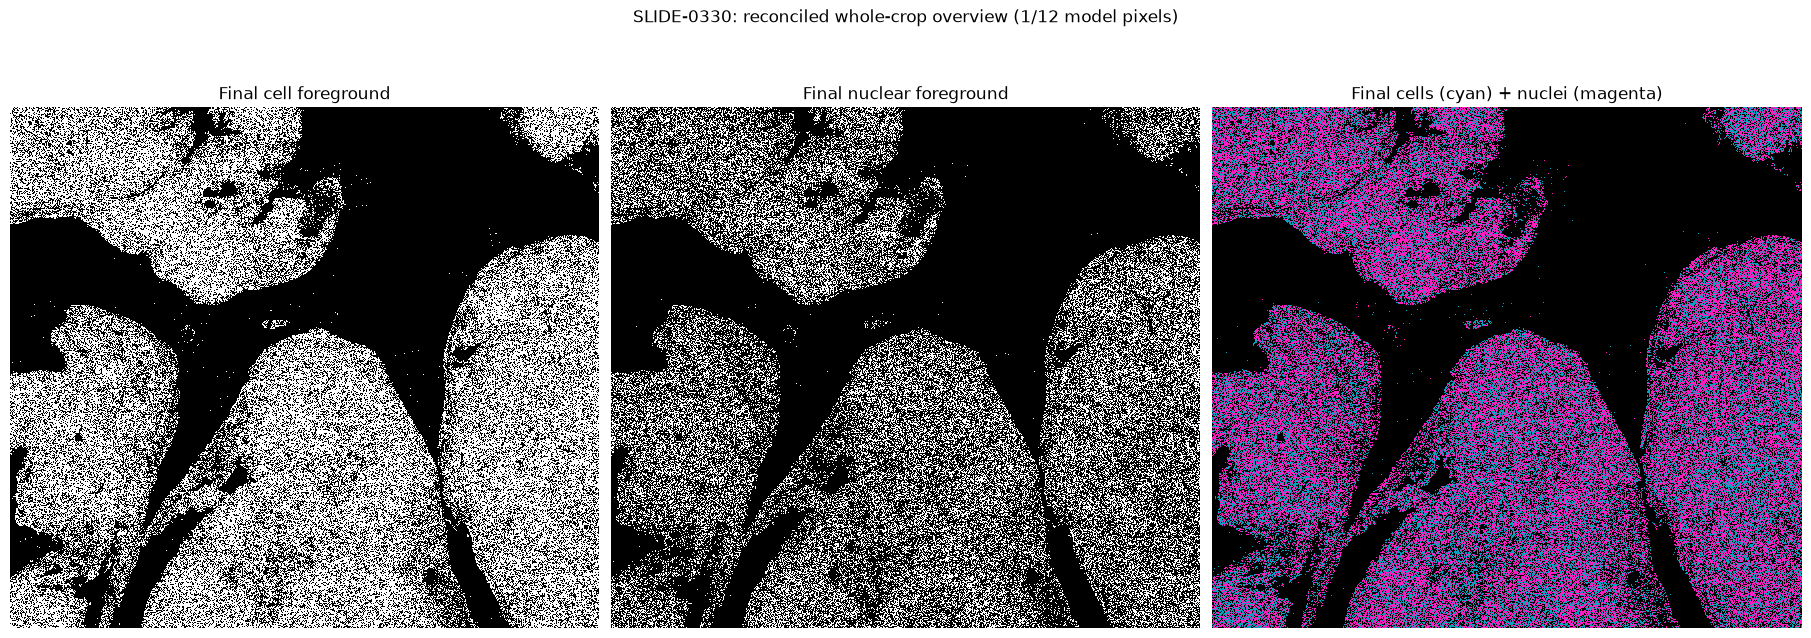

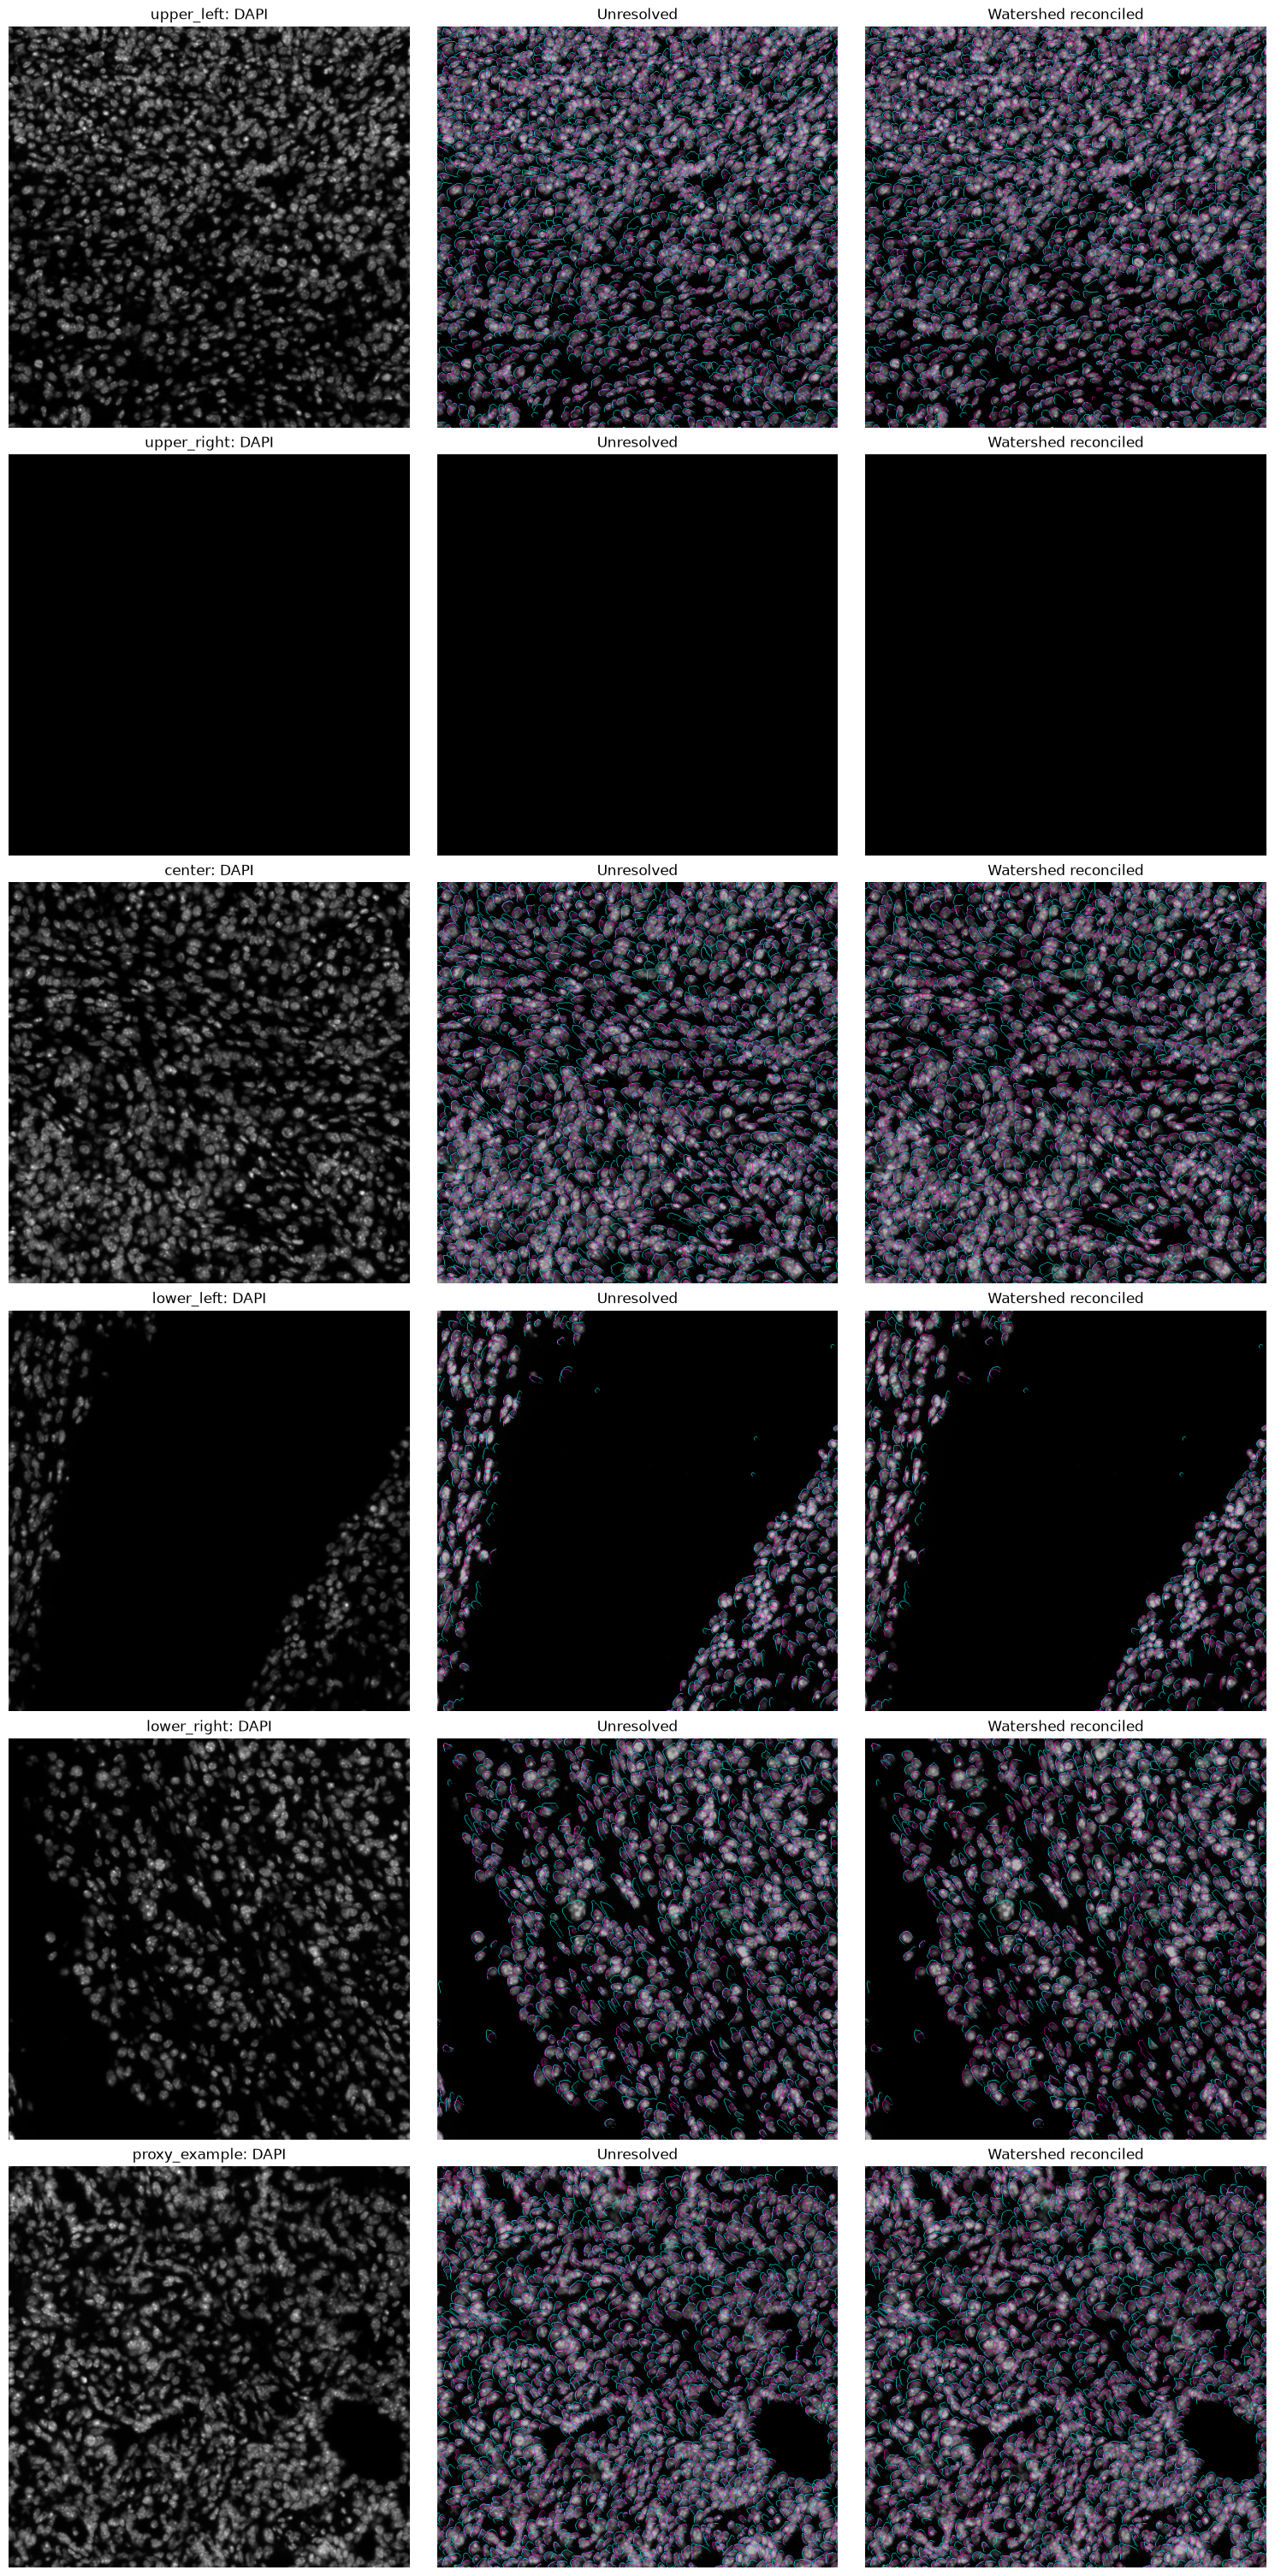

{'qc_directory': '/data1/lowes/ratnayn/Codex/codex-scratch/mIF-pipeline/instanseg_watershed_production_smoke_all_channel_crop/SLIDE-0330/visual_qc', 'overview_step': 12, 'local_fields': ['upper_left', 'upper_right', 'center', 'lower_left', 'lower_right', 'proxy_example']}


In [8]:
QC_DIR = OUTPUT_DIR / 'visual_qc'
QC_DIR.mkdir(parents=True, exist_ok=True)
QC_CROP_SIZE_MODEL = 768
QC_OVERVIEW_MAX_PIXELS = 1800

reconciled = zarr.open(str(RECONCILED_ZARR), mode='r')
if reconciled.attrs.get('status') != 'complete' or reconciled.shape != (2, *model_shape):
    raise RuntimeError('Run and validate the reconciled Zarr before visual QC.')

overview_step = max(1, int(np.ceil(max(model_shape) / QC_OVERVIEW_MAX_PIXELS)))
overview_nuclei = np.asarray(reconciled[0, ::overview_step, ::overview_step]) > 0
overview_cells = np.asarray(reconciled[1, ::overview_step, ::overview_step]) > 0
overview_rgb = np.zeros((*overview_cells.shape, 3), dtype=np.float32)
overview_rgb[overview_cells] = (0.0, 0.65, 0.75)
overview_rgb[overview_nuclei] = (1.0, 0.1, 0.75)
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
axes[0].imshow(overview_cells, cmap='gray', interpolation='nearest')
axes[0].set_title('Final cell foreground')
axes[1].imshow(overview_nuclei, cmap='gray', interpolation='nearest')
axes[1].set_title('Final nuclear foreground')
axes[2].imshow(overview_rgb, interpolation='nearest')
axes[2].set_title('Final cells (cyan) + nuclei (magenta)')
for axis in axes:
    axis.axis('off')
fig.suptitle(f'{SLIDE_ID}: reconciled whole-crop overview (1/{overview_step} model pixels)')
fig.savefig(QC_DIR / f'{SLIDE_ID}_whole_crop_overview.png', dpi=180, bbox_inches='tight')
plt.show()

def first_label_center_in_range(array, lower, upper):
    if lower >= upper:
        return None
    for y0 in range(0, array.shape[0], ROW_CHUNK):
        y1 = min(array.shape[0], y0 + ROW_CHUNK)
        block = np.asarray(array[y0:y1])
        hits = np.argwhere((block >= lower) & (block < upper))
        if hits.size:
            y, x = hits[0]
            return int(y0 + y), int(x)
    return None

half = QC_CROP_SIZE_MODEL // 2
fixed_centers = [
    ('upper_left', model_shape[0] // 4, model_shape[1] // 4),
    ('upper_right', model_shape[0] // 4, 3 * model_shape[1] // 4),
    ('center', model_shape[0] // 2, model_shape[1] // 2),
    ('lower_left', 3 * model_shape[0] // 4, model_shape[1] // 4),
    ('lower_right', 3 * model_shape[0] // 4, 3 * model_shape[1] // 4),
]
proxy_center = first_label_center_in_range(reconciled[0], proxy_start_id, proxy_stop_id)
qc_centers = fixed_centers + ([('proxy_example', *proxy_center)] if proxy_center else [])

def label_boundaries(labels):
    boundary = np.zeros(labels.shape, dtype=bool)
    boundary[1:] |= labels[1:] != labels[:-1]
    boundary[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    return boundary & (labels > 0)

def overlay_boundaries(dapi, nuclei, cells):
    lo, hi = np.percentile(dapi, (1, 99.5))
    gray = np.clip((dapi.astype(np.float32) - lo) / max(hi - lo, 1), 0, 1)
    rgb = np.repeat(gray[..., None], 3, axis=-1) * 0.7
    rgb[label_boundaries(cells)] = (0.0, 1.0, 1.0)
    rgb[label_boundaries(nuclei)] = (1.0, 0.0, 0.8)
    return rgb

with tifffile.TiffFile(CROP_OME) as handle:
    crop_store = handle.series[0].aszarr(level=0)
    crop_source = zarr.open(crop_store, mode='r')
    try:
        fig, axes = plt.subplots(len(qc_centers), 3, figsize=(15, 5 * len(qc_centers)), constrained_layout=True)
        for row, (name, center_y, center_x) in enumerate(qc_centers):
            y0 = max(0, min(model_shape[0] - QC_CROP_SIZE_MODEL, center_y - half))
            x0 = max(0, min(model_shape[1] - QC_CROP_SIZE_MODEL, center_x - half))
            y1, x1 = y0 + QC_CROP_SIZE_MODEL, x0 + QC_CROP_SIZE_MODEL
            unresolved_nuclei = np.asarray(raw[0, y0:y1, x0:x1])
            unresolved_cells = np.asarray(raw[1, y0:y1, x0:x1])
            final_nuclei_crop = np.asarray(reconciled[0, y0:y1, x0:x1])
            final_cells_crop = np.asarray(reconciled[1, y0:y1, x0:x1])
            native_y0 = int(np.floor(y0 * CROP_HEIGHT / model_shape[0]))
            native_y1 = int(np.ceil(y1 * CROP_HEIGHT / model_shape[0]))
            native_x0 = int(np.floor(x0 * CROP_WIDTH / model_shape[1]))
            native_x1 = int(np.ceil(x1 * CROP_WIDTH / model_shape[1]))
            dapi_native = np.asarray(crop_source.oindex[REFERENCE_CHANNEL_ID, slice(native_y0, native_y1), slice(native_x0, native_x1)])
            dapi = ndi.zoom(dapi_native, (QC_CROP_SIZE_MODEL / dapi_native.shape[0], QC_CROP_SIZE_MODEL / dapi_native.shape[1]), order=1)
            dapi = dapi[:QC_CROP_SIZE_MODEL, :QC_CROP_SIZE_MODEL]
            axes[row, 0].imshow(dapi, cmap='gray')
            axes[row, 0].set_title(f'{name}: DAPI')
            axes[row, 1].imshow(overlay_boundaries(dapi, unresolved_nuclei, unresolved_cells))
            axes[row, 1].set_title('Unresolved')
            axes[row, 2].imshow(overlay_boundaries(dapi, final_nuclei_crop, final_cells_crop))
            axes[row, 2].set_title('Watershed reconciled')
            for axis in axes[row]:
                axis.axis('off')
        fig.savefig(QC_DIR / f'{SLIDE_ID}_local_qc.png', dpi=180, bbox_inches='tight')
        plt.show()
    finally:
        crop_store.close()
print({'qc_directory': str(QC_DIR), 'overview_step': overview_step, 'local_fields': [name for name, *_ in qc_centers]})